In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import classification_report, roc_auc_score, f1_score


df_model = pd.read_csv('C:\\Users\\Samak\\OneDrive\\เดสก์ท็อป\\Fraud Detection\\Data\\fraud_oracle_fe.csv')

In [2]:
X = df_model.drop('FraudFound_P', axis=1)
y = df_model['FraudFound_P']

# คำนวณ scale_pos_weight สำหรับ XGBoost (จำนวนคลาสปกติ / จำนวนคลาส Fraud)
neg_classes = (y == 0).sum()
pos_classes = (y == 1).sum()
scale_pos_weight = neg_classes / pos_classes

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build Pipeline for impute age = 0
age_pipeline = Pipeline(steps=[
        ('impute_median', SimpleImputer(strategy='median'))
    ])
    
# Add pipeline to the column transformer
preprocessor = ColumnTransformer(transformers=[
    ('age_impute', age_pipeline, ['Age'])
], remainder='passthrough')

models = {
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'classifier__subsample': [0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
        'params': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [-1, 10, 20, 30],
            'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'classifier__num_leaves': [31, 50, 100]
        }
    }
}

In [3]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
results = {}

print('--- เริ่ม Training, Hyperparameter & Threshold Tuning ---\n')

for name, m in models.items():
    print(f"Training {name}...")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', m['model'])
    ])
    
    # RandomizedSearchCV
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=m['params'],
        n_iter=10,
        cv=cv,
        scoring='recall', 
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    # Best model and Probabilities
    best_model = search.best_estimator_
    y_prob = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    # ---------------------------------------------------------
    # 🎯 กระบวนการ Threshold Tuning (รายโมเดล)
    # ---------------------------------------------------------
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    
    # ต้องการ Recall ไม่ต่ำกว่า 65% 
    target_recall = 0.65 
    valid_indices = np.where(recalls >= target_recall)[0]
    
    if len(valid_indices) > 0:
        # หากมี Threshold ที่ทำ Recall ได้เกิน 65% -> ให้เลือกจุดที่ Precision สูงที่สุด
        best_precision_idx = valid_indices[np.argmax(precisions[valid_indices])]
        optimal_thresh = thresholds[best_precision_idx] if best_precision_idx < len(thresholds) else thresholds[-1]
    else:
        # (Fallback) หากโมเดลแย่มากจนทำ Recall ไม่ถึง 65% เลย -> ให้หาจุดที่ F2-Score สูงสุดแทน
        f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)
        optimal_thresh = thresholds[np.argmax(f2_scores)]

    # นำ Threshold ที่ดีที่สุดของโมเดลนี้ไปใช้ทำนายผล
    y_pred_tuned = (y_prob >= optimal_thresh).astype(int)

    # Save results
    results[name] = {
        'best_params': search.best_params_,
        'roc_auc': roc_auc,
        'optimal_threshold': optimal_thresh,
        'f1_score_tuned': f1_score(y_test, y_pred_tuned),
        'report_tuned': classification_report(y_test, y_pred_tuned)
    }
    print(f'{name} Finished Train (Optimal Threshold: {optimal_thresh:.4f})\n')

print('\n' + '=' * 60)
print('--- สรุปผลการ Train & Threshold Tuning (Target Recall >= 65%) ---')
print('=' * 60)

for name, res in results.items():
    print(f"\n🚀 โมเดล: {name}")
    print(f"พารามิเตอร์ที่ดีที่สุด: {res['best_params']}")
    print(f"ROC-AUC Score: {res['roc_auc']:.4f}")
    print(f"🎯 Threshold ที่ปรับจูนแล้ว: {res['optimal_threshold']:.4f}")
    print(f"F1-Score (Tuned):      {res['f1_score_tuned']:.4f}")
    print("Classification Report (ประเมินด้วย Threshold ใหม่):")
    print(res['report_tuned'])
    print("-" * 60)

--- เริ่ม Training, Hyperparameter & Threshold Tuning ---

Training RandomForest...
RandomForest Finished Train (Optimal Threshold: 0.5315)

Training XGBoost...
XGBoost Finished Train (Optimal Threshold: 0.5946)

Training LightGBM...
LightGBM Finished Train (Optimal Threshold: 0.5776)


--- สรุปผลการ Train & Threshold Tuning (Target Recall >= 65%) ---

🚀 โมเดล: RandomForest
พารามิเตอร์ที่ดีที่สุด: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': 10}
ROC-AUC Score: 0.8147
🎯 Threshold ที่ปรับจูนแล้ว: 0.5315
F1-Score (Tuned):      0.2508
Classification Report (ประเมินด้วย Threshold ใหม่):
              precision    recall  f1-score   support

           0       0.97      0.77      0.86      2899
           1       0.16      0.65      0.25       185

    accuracy                           0.77      3084
   macro avg       0.56      0.71      0.56      3084
weighted avg       0.92      0.77      0.82      3084

---------------------------------

c:\Users\Samak\OneDrive\เดสก์ท็อป\Fraud Detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


- LightGBM Perform a best Result

C:\Users\Samak\AppData\Local\Temp\ipykernel_16232\1032328987.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


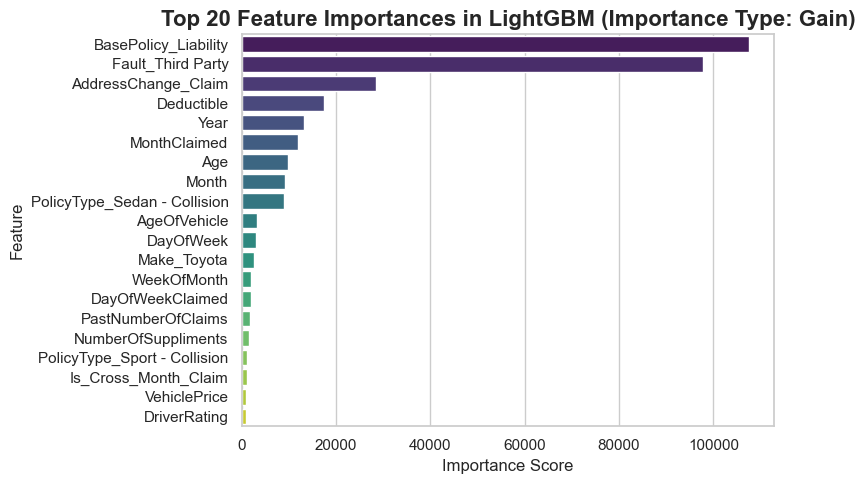

--- 🌟 Top 10 ปัจจัยที่บ่งชี้การทุจริตมากที่สุด ---
                     Feature    Importance
        BasePolicy_Liability 107462.204315
           Fault_Third Party  97863.684138
         AddressChange_Claim  28401.381351
                  Deductible  17495.757133
                        Year  13146.887627
                MonthClaimed  11962.979589
                         Age   9711.987717
                       Month   9129.344188
PolicyType_Sedan - Collision   8954.655903
                AgeOfVehicle   3293.376002


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

age_pipeline = Pipeline([
    ('impute_median', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('age_impute', age_pipeline, ['Age'])
    ],
    remainder='passthrough'
)

# 2. แปลงข้อมูล X ทั้งหมด (เพื่อใช้ในการเทรนหา Feature Importance)
X_processed = preprocessor.fit_transform(X)

feature_names = ['Age'] + [c for c in X.columns if c != 'Age']

# Train LightGBM 
best_lgbm = LGBMClassifier(
    num_leaves=31, 
    n_estimators=100, 
    max_depth=20,
    importance_type='gain', 
    learning_rate=0.01,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

best_lgbm.fit(X_processed, y)

# Feature Importance 
importances = best_lgbm.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 20 Features
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(20), 
    palette='viridis'
)

plt.title('Top 20 Feature Importances in LightGBM (Importance Type: Gain)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# แสดงผล Top 10 เป็นตารางข้อความ
print("--- 🌟 Top 10 ปัจจัยที่บ่งชี้การทุจริตมากที่สุด ---")
print(feature_importance_df.head(10).to_string(index=False))

### Best Model: LightGBM
#### จากการเปรียบเทียบ LightGBM คือโมเดลที่ทำผลงานได้ดีที่สุดในทุกมิติ โดยมีรายละเอียดดังนี้:

##### - Best Hyperparameters: num_leaves=31, n_estimators=100, max_depth=20, learning_rate=0.01

##### - ROC-AUC Score: 0.8358 (ประสิทธิภาพการแยกแยะระหว่างคนปกติและมิจฉาชีพสูงที่สุด)

##### - Optimal Threshold: 0.5776

##### -ประสิทธิภาพระดับ Business (บน Test Set):

- Recall = 0.78: สามารถจับเคสทุจริตได้ถึง 78% (เกินเป้าหมายที่ตั้งไว้)

- Precision = 0.16: รักษาระดับความแม่นยำไว้ได้ดีที่สุดเมื่อเทียบกับโมเดลอื่นที่ระดับ Recall เท่าๆ กัน

### ปัจจัยหลักที่ใช้จับทุจริต (Top Feature Insights)
#### จากการวิเคราะห์ Feature Importance (Gain) ของ LightGBM พบว่าโมเดลใช้ปัจจัยเหล่านี้เป็นตัวตัดสินหลัก:

##### - เกราะป้องกันคนบริสุทธิ์: BasePolicy_Liability และ Fault_Third Party (หากเป็นประกันแบบบุคคลภายนอก หรือคู่กรณีเป็นฝ่ายผิด โมเดลมักจะมองว่าไม่ใช่ Fraud ทันที)

##### - พฤติกรรมน่าสงสัย: AddressChange_Claim (การเพิ่งย้ายที่อยู่ก่อนเคลมประกันไม่นาน เป็นปัจจัยความเสี่ยงสูง)

##### - ปัจจัยทางการเงินและอายุ: Deductible (ค่าเสียหายส่วนแรก) และ Age มีผลอย่างมีนัยสำคัญต่อการแยกแยะกลุ่มเสี่ยง

In [10]:
# Top 10 Features 
top_10_cols = [
    'BasePolicy_Liability', 
    'Fault_Third Party', 
    'AddressChange_Claim', 
    'Deductible', 
    'Year', 
    'MonthClaimed', 
    'Age', 
    'Month', 
    'PolicyType_Sedan - Collision', 
    'AgeOfVehicle'
]

X_lite = df_model[top_10_cols]
y_lite = df_model['FraudFound_P']

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_lite, y_lite, test_size=0.2, random_state=42, stratify=y_lite)

# 4. เทรนโมเดล LightGBM (Lite Version)
lite_model = LGBMClassifier(
    num_leaves=31, n_estimators=100, max_depth=20, learning_rate=0.01,
    class_weight='balanced', random_state=42, verbose=-1
)
lite_model.fit(X_train, y_train)

# Optimal Threshold 
y_prob = lite_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
valid_indices = np.where(recalls >= 0.65)[0]

if len(valid_indices) > 0:
    best_precision_idx = valid_indices[np.argmax(precisions[valid_indices])]
    optimal_thresh = thresholds[best_precision_idx] if best_precision_idx < len(thresholds) else thresholds[-1]
else:
    optimal_thresh = 0.5 

print(f"✅ เทรน Lite Model เสร็จสิ้น! (Optimal Threshold: {optimal_thresh:.4f})")

report = classification_report(y_test, (y_prob >= optimal_thresh).astype(int))
print("\n📊 Classification Report (Lite Model with Tuned Threshold):")
print(report)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score (Lite Model): {roc_auc:.4f}")

model_package = {
    'model': lite_model,
    'threshold': optimal_thresh,
    'features': top_10_cols
}

✅ เทรน Lite Model เสร็จสิ้น! (Optimal Threshold: 0.6108)

📊 Classification Report (Lite Model with Tuned Threshold):
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2899
           1       0.20      0.66      0.31       185

    accuracy                           0.83      3084
   macro avg       0.59      0.75      0.61      3084
weighted avg       0.93      0.83      0.86      3084

ROC-AUC Score (Lite Model): 0.8565


### We will use this model in Streamlit App

In [11]:
# Save Lite Model
import joblib

joblib.dump(model_package, 'fraud_lite_model.pkl')
print("✅ เซฟไฟล์ 'fraud_lite_model.pkl' เรียบร้อย พร้อมสำหรับ Streamlit!")

✅ เซฟไฟล์ 'fraud_lite_model.pkl' เรียบร้อย พร้อมสำหรับ Streamlit!
